# Two-Qubit GST Optimizer Benchmark

This notebook follows one experiment flow:

1. Define the GST model, dataset, variables, and residual/Jacobian functions.
2. Run the built-in pyGSTi LM solver.
3. Run the custom POUNDERS/PyROL optimizer.
4. Compare both fitted models using gauge-independent data-space metrics, with heatmaps only as diagnostics.


## 1. Define the Model and Variables

This section builds the two-qubit GST model, chooses the fiducials/germs/max-length schedule, generates the synthetic dataset, and defines the functions shared by both solvers.


### 1.1 Imports and Local Optimizer Path


In [19]:
import pygsti
import warnings
import numpy as np
import sys
from pathlib import Path
from scipy.linalg import LinAlgWarning
import pkgutil
import pygsti.modelpacks as modelpacks
from pygsti.modelpacks import smq2Q_XYICNOT
from pygsti.protocols import StandardGSTDesign
from pygsti.optimize import SimplerLMOptimizer

_cwd = Path.cwd()
for _repo_root in (_cwd, _cwd.parent):
    _pounders_path = _repo_root / "pounders" / "py"
    if (_pounders_path / "gradient_pounders.py").exists():
        if str(_pounders_path) not in sys.path:
            sys.path.insert(0, str(_pounders_path))
        break
else:
    raise FileNotFoundError("Could not find local pounders/py/gradient_pounders.py")

import gradient_pounders as pounders
import importlib
import importlib.util
pounders = importlib.reload(pounders)

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=LinAlgWarning)
np.seterr(divide="ignore", invalid="ignore", over="ignore")

np.set_printoptions(precision=4, suppress=True)

### 1.2 Experiment Configuration


In [20]:
# -----------------------------
# Main experiment configuration
# -----------------------------

# GST circuit design. The 2Q modelpack provides the fiducials and germs.
MAX_LENGTHS = [1, 2, 4, 8, 16]

# Synthetic data generation. This is the benchmark data both solvers fit.
N_SAMPLES = 500
DATA_SEED = 100
OP_NOISE = 0.01
SPAM_NOISE = 0.005
SAMPLE_ERROR = "multinomial"

# Built-in pyGSTi LM baseline.
RUN_LM_BASELINE = True
PYGSTI_BASELINE_MODES = ("full TP",)
MEMORY_LIMIT_BYTES = 3 * (1024 ** 3)
LM_MAXITER = 100
LM_MAXFEV = 100
LM_TOL = 1e-6

# Custom POUNDERS/PyROL run. None means use all GST circuits.
RUN_POUNDERS = True
POUNDERS_NUM_CIRCUITS = None
POUNDERS_NFMAX = 60
POUNDERS_GTOL = 1e-13
POUNDERS_INITIAL_DELTA = 0.1
PREFER_PYROL = True

print("MAX_LENGTHS:", MAX_LENGTHS)
print("N_SAMPLES:", N_SAMPLES)
print("RUN_LM_BASELINE:", RUN_LM_BASELINE)
print("RUN_POUNDERS:", RUN_POUNDERS)
print("POUNDERS_NUM_CIRCUITS:", POUNDERS_NUM_CIRCUITS)

MAX_LENGTHS: [1, 2, 4, 8, 16]
N_SAMPLES: 500
RUN_LM_BASELINE: True
RUN_POUNDERS: True
POUNDERS_NUM_CIRCUITS: None


### 1.3 Build the Two-Qubit Target Model


In [21]:
def build_two_qubit_target_model():
    """Return the 2Q XY+CNOT target model and its modelpack."""
    return smq2Q_XYICNOT.target_model(), "pygsti.modelpacks.smq2Q_XYICNOT.target_model()", smq2Q_XYICNOT


target_model, construction_method, modelpack = build_two_qubit_target_model()
processor_spec = modelpack.processor_spec() if hasattr(modelpack, "processor_spec") else None

theta0 = target_model.to_vector()
print("Built target model using:", construction_method)
print("Processor spec:", type(processor_spec) if processor_spec is not None else None)
print("Model type:", type(target_model))
print("Number of model parameters:", theta0.size)
print("Operation labels:", [str(label) for label in target_model.operations.keys()])
print("Preparation labels:", [str(label) for label in target_model.preps.keys()])
print("POVM labels:", [str(label) for label in target_model.povms.keys()])

Built target model using: pygsti.modelpacks.smq2Q_XYICNOT.target_model()
Processor spec: <class 'pygsti.processors.processorspec.QubitProcessorSpec'>
Model type: <class 'pygsti.models.explicitmodel.ExplicitOpModel'>
Number of model parameters: 1616
Operation labels: ['[]', 'Gxpi2:1', 'Gypi2:1', 'Gxpi2:0', 'Gypi2:0', 'Gcnot:0:1']
Preparation labels: ['rho0']
POVM labels: ['Mdefault']


### 1.4 GST Design Ingredients

The modelpack supplies the preparation fiducials, measurement fiducials, and germs. A GST circuit has the form

`rho0 -> prep fiducial -> germ^L -> measurement fiducial -> POVM`.


In [22]:
prep_fiducials = modelpack.prep_fiducials()
meas_fiducials = modelpack.meas_fiducials()
germs = modelpack.germs()
max_lengths = MAX_LENGTHS

print("prep fiducials:", len(prep_fiducials))
print("meas fiducials:", len(meas_fiducials))
print("germs:", len(germs))
print("max lengths:", max_lengths)

prep fiducials: 16
meas fiducials: 11
germs: 15
max lengths: [1, 2, 4, 8, 16]


### 1.5 Build the Noisy Synthetic Dataset


In [23]:
data_generation_model = target_model.depolarize(
    op_noise=OP_NOISE,
    spam_noise=SPAM_NOISE,
    seed=DATA_SEED,
)

# Alternative controlled benchmarks you can try later:
# data_generation_model = target_model.rotate(max_rotate=0.02, seed=DATA_SEED)
# data_generation_model = target_model.rotate(max_rotate=0.04, seed=DATA_SEED).depolarize(
#     op_noise=0.02,
#     spam_noise=0.01,
#     seed=DATA_SEED,
# )

print("OP_NOISE:", OP_NOISE)
print("SPAM_NOISE:", SPAM_NOISE)
print("N_SAMPLES:", N_SAMPLES)
print("SAMPLE_ERROR:", SAMPLE_ERROR)

OP_NOISE: 0.01
SPAM_NOISE: 0.005
N_SAMPLES: 500
SAMPLE_ERROR: multinomial


In [24]:
design_source = processor_spec if processor_spec is not None else target_model
gst_design = StandardGSTDesign(
    design_source,
    prep_fiducials,
    meas_fiducials,
    germs,
    max_lengths,
)

list_of_experiments = list(gst_design.all_circuits_needing_data)
print("Created StandardGSTDesign")
print("Total GST circuits:", len(list_of_experiments))

for i, circuit in enumerate(list_of_experiments[:10]):
    print(f"Circuit {i:3d} | length = {len(circuit):3d} | {circuit}")

dataset = pygsti.data.simulate_data(
    data_generation_model,
    gst_design,
    num_samples=N_SAMPLES,
    sample_error=SAMPLE_ERROR,
    seed=DATA_SEED,
)
print("Generated synthetic 2Q GST dataset")

Created StandardGSTDesign
Total GST circuits: 8740
Circuit   0 | length =   0 | Qubit 0 -----
Qubit 1 -----

Circuit   1 | length =   1 | Qubit 0 ---|     |---
Qubit 1 ---|Gxpi2|---

Circuit   2 | length =   1 | Qubit 0 ---|     |---
Qubit 1 ---|Gypi2|---

Circuit   3 | length =   2 | Qubit 0 ---|     |-|     |---
Qubit 1 ---|Gxpi2|-|Gxpi2|---

Circuit   4 | length =   1 | Qubit 0 ---|Gxpi2|---
Qubit 1 ---|     |---

Circuit   5 | length =   1 | Qubit 0 ---|Gypi2|---
Qubit 1 ---|     |---

Circuit   6 | length =   2 | Qubit 0 ---|Gxpi2|-|Gxpi2|---
Qubit 1 ---|     |-|     |---

Circuit   7 | length =   2 | Qubit 0 ---|Gxpi2|-|     |---
Qubit 1 ---|     |-|Gxpi2|---

Circuit   8 | length =   2 | Qubit 0 ---|Gxpi2|-|     |---
Qubit 1 ---|     |-|Gypi2|---

Circuit   9 | length =   2 | Qubit 0 ---|Gypi2|-|     |---
Qubit 1 ---|     |-|Gxpi2|---

Generated synthetic 2Q GST dataset


### 1.6 Shared Custom-Optimizer Interface

These functions expose the GST problem as `p(x)`, `Jac[p(x)]`, `Var[p(x)]`, observed frequencies `f`, `Var[f]`, and residual/Jacobian pairs. They are defined before either solver is run so both solver paths use the same model, circuits, and dataset.


In [25]:
def _model_num_params(model):
    value = model.num_params
    return value() if callable(value) else int(value)


def get_current_gst_model():
    """Return the model used by the custom optimizer interface.

    Priority:
    1. `optimizer_model`, if you set it manually
    2. `current_gst_model`, kept for backward compatibility
    3. `target_model`, the default 1616-parameter model
    4. `fit_model`, only as a fallback after LM fitting
    """
    if "optimizer_model" in globals() and optimizer_model is not None:
        return optimizer_model
    if "current_gst_model" in globals() and current_gst_model is not None:
        return current_gst_model
    if "target_model" in globals() and target_model is not None:
        return target_model
    if "fit_model" in globals() and fit_model is not None:
        return fit_model
    raise RuntimeError("Run the target-model cell first, or set current_gst_model manually.")


def _resolve_model_template(model_template=None):
    if model_template is not None:
        return model_template
    return get_current_gst_model()


def _resolve_circuits(circuits=None):
    if circuits is not None:
        return list(circuits)
    if "list_of_experiments" in globals() and list_of_experiments is not None:
        return list(list_of_experiments)
    if "gst_design" in globals() and gst_design is not None:
        return list(gst_design.all_circuits_needing_data)
    raise RuntimeError("Pass circuits or run the GST-design cell first.")


def _copy_model_at_x(x, model_template=None):
    model = _resolve_model_template(model_template).copy()
    x = np.asarray(x, dtype=float)
    if len(x) != _model_num_params(model):
        raise ValueError(
            f"x has length {len(x)}, but the model has {_model_num_params(model)} parameters."
        )
    model.from_vector(x, close=False)
    return model


def _outcomes_for_circuit(circuit, model, data_for_outcomes=None):
    if data_for_outcomes is not None:
        return list(data_for_outcomes[circuit].outcomes)
    return list(model.probabilities(circuit).keys())


def _shot_count_for_circuit(data, circuit, circuit_index, num_samples):
    if data is not None:
        return float(data[circuit].total)
    if num_samples is None:
        return None
    if np.isscalar(num_samples):
        return float(num_samples)
    return float(num_samples[circuit_index])


def gst_model_function(
    x,
    model_template=None,
    circuits=None,
    data_for_outcomes=None,
    num_samples=None,
    return_labels=False,
):

    model = _copy_model_at_x(x, model_template)
    circuits = _resolve_circuits(circuits)

    probabilities_by_circuit = model.bulk_probabilities(circuits)
    derivatives_by_circuit = model.sim.bulk_dprobs(circuits)

    p_values = []
    jacobian_rows = []
    var_p_values = []
    labels = []

    for circuit_index, circuit in enumerate(circuits):
        outcomes = _outcomes_for_circuit(circuit, model, data_for_outcomes)
        probabilities = probabilities_by_circuit[circuit]
        derivatives = derivatives_by_circuit[circuit]
        shots = _shot_count_for_circuit(data_for_outcomes, circuit, circuit_index, num_samples)

        for outcome in outcomes:
            p = float(probabilities.get(outcome, 0.0))
            p_clipped = min(max(p, 0.0), 1.0)
            p_values.append(p)
            jacobian_rows.append(np.asarray(derivatives[outcome], dtype=float))
            var_p_values.append(p_clipped * (1.0 - p_clipped) / shots if shots else 0.0)
            labels.append((circuit, outcome))

    p_vector = np.asarray(p_values, dtype=float)
    jacobian = np.vstack(jacobian_rows) if jacobian_rows else np.empty((0, _model_num_params(model)))
    var_p = np.asarray(var_p_values, dtype=float)

    if return_labels:
        return p_vector, jacobian, var_p, labels
    return p_vector, jacobian, var_p


def gst_data_function(data=None, circuits=None, return_labels=False):
    """Return observed frequencies f and diagonal Var[f] from a pyGSTi DataSet."""
    if data is None:
        if "dataset" not in globals() or dataset is None:
            raise RuntimeError("Pass data or run the dataset cell first.")
        data = dataset

    circuits = _resolve_circuits(circuits)
    f_values = []
    var_f_values = []
    labels = []

    for circuit in circuits:
        row = data[circuit]
        total = float(row.total)
        fractions = row.fractions

        for outcome in row.outcomes:
            f = float(fractions.get(outcome, 0.0))
            f_clipped = min(max(f, 0.0), 1.0)
            f_values.append(f)
            var_f_values.append(f_clipped * (1.0 - f_clipped) / total if total > 0 else np.nan)
            labels.append((circuit, outcome))

    f_vector = np.asarray(f_values, dtype=float)
    var_f = np.asarray(var_f_values, dtype=float)

    if return_labels:
        return f_vector, var_f, labels
    return f_vector, var_f

In [26]:
optimizer_model = target_model
# optimizer_model = fit_model

active_model = get_current_gst_model()
x_current = active_model.to_vector()

# Use all GST circuits here.
gst_circuits = list_of_experiments

px_k, jac_px_k, var_px_k, p_labels_demo = gst_model_function(
    x_current,
    model_template=active_model,
    circuits=gst_circuits,
    data_for_outcomes=dataset,
    return_labels=True,
)
f_k, var_f_k, f_labels_demo = gst_data_function(
    dataset,
    circuits=gst_circuits,
    return_labels=True,
)

print("Current model type:", type(active_model))
print("Current parameter vector shape:", x_current.shape)
print("px_k shape:", px_k.shape)
print("jac_px_k shape:", jac_px_k.shape)
print("var_px_k shape:", var_px_k.shape)
print("f_k shape:", f_k.shape)
print("var_f_k shape:", var_f_k.shape)

Current model type: <class 'pygsti.models.explicitmodel.ExplicitOpModel'>
Current parameter vector shape: (1616,)
px_k shape: (34960,)
jac_px_k shape: (34960, 1616)
var_px_k shape: (34960,)
f_k shape: (34960,)
var_f_k shape: (34960,)


In [27]:
# Residual and Jacobian wrapper for GST optimizers.
# Uses the existing gst_model_function and gst_data_function defined above.

def gst_residual_and_jacobian(
    x,
    model_template=None,
    circuits=None,
    data=None,
    weighted=False,
    variance_source="data",
    variance_floor=1e-12,
    jacobian_layout="residuals_by_parameters",
    return_labels=False,
):

    if data is None:
        if "dataset" not in globals() or dataset is None:
            raise RuntimeError("Pass data or run the dataset cell first.")
        data = dataset

    x = np.asarray(x, dtype=float).reshape(-1)
    circuits = _resolve_circuits(circuits)

    p_vec, jac_p, var_p, p_labels = gst_model_function(
        x,
        model_template=model_template,
        circuits=circuits,
        data_for_outcomes=data,
        return_labels=True,
    )
    f_vec, var_f, f_labels = gst_data_function(
        data=data,
        circuits=circuits,
        return_labels=True,
    )

    if p_labels != f_labels:
        raise ValueError("Model and data labels do not match. Check circuits/outcome ordering.")

    residual = p_vec - f_vec
    jacobian = np.asarray(jac_p, dtype=float)

    if weighted:
        if variance_source == "data":
            variance = var_f
        elif variance_source == "model":
            variance = var_p
        elif variance_source == "combined":
            variance = var_f + var_p
        else:
            raise ValueError('variance_source must be "data", "model", or "combined".')

        sigma = np.sqrt(np.maximum(np.asarray(variance, dtype=float), variance_floor))
        residual = residual / sigma
        jacobian = jacobian / sigma[:, None]

    if jacobian_layout == "residuals_by_parameters":
        output_jacobian = jacobian
    elif jacobian_layout == "pounders":
        output_jacobian = jacobian.T
    else:
        raise ValueError('jacobian_layout must be "residuals_by_parameters" or "pounders".')

    if return_labels:
        return residual, output_jacobian, p_labels
    return residual, output_jacobian


def gst_pounders_residual_function(x, **kwargs):
    """Convenience wrapper with the Jacobian layout expected by gradient_pounders.pouders.

    gradient_pounders.pouders expects fun(x) to return:
        residual vector F with shape (m,)
        Jacobian J with shape (n, m)
    """
    kwargs.setdefault("jacobian_layout", "pounders")
    return gst_residual_and_jacobian(x, **kwargs)

## 2. Run the Built-In pyGSTi LM Solver

This section runs pyGSTi's `SimplerLMOptimizer` through `StandardGST` and extracts the fitted model used for diagnostics.


In [28]:
def make_builtin_lm_optimizer():
    return SimplerLMOptimizer(
        maxiter=LM_MAXITER,
        maxfev=LM_MAXFEV,
        tol=LM_TOL,
        init_munu="auto",
        oob_action="reject",
    )


if RUN_LM_BASELINE:
    protocol_data = pygsti.protocols.ProtocolData(gst_design, dataset)
    protocol = pygsti.protocols.StandardGST(
        modes=PYGSTI_BASELINE_MODES,
        target_model=target_model,
        optimizer=make_builtin_lm_optimizer(),
        verbosity=2,
    )

    results = protocol.run(protocol_data, memlimit=MEMORY_LIMIT_BYTES)
    print("pyGSTi StandardGST baseline completed")
    print("Modes:", PYGSTI_BASELINE_MODES)
    print("Optimizer: pyGSTi SimplerLMOptimizer (LM-style solver)")
    print("LM settings:", {"maxiter": LM_MAXITER, "maxfev": LM_MAXFEV, "tol": LM_TOL})
    print(type(results))
else:
    results = None
    print("Skipped pyGSTi LM baseline because RUN_LM_BASELINE=False")

-- Std Practice:  Iter 1 of 1  (full TP) --: 
  --- Iterative GST: [##################################################] 100.0%  8740 circuits ---
pyGSTi StandardGST baseline completed
Modes: ('full TP',)
Optimizer: pyGSTi SimplerLMOptimizer (LM-style solver)
LM settings: {'maxiter': 100, 'maxfev': 100, 'tol': 1e-06}
<class 'pygsti.protocols.gst.ModelEstimateResults'>


### 2.1 Built-In LM Data-Space Diagnostics


Using estimate 'full TP' model 'stdgaugeopt'


/usr/local/lib/python3.11/site-packages/pygsti/tools/legacytools.py:38: UserWarning: The function fraction is deprecated, and may not be present in future versions of pygsti.
    Please use DataSetRow.fractions instead.
  _warnings.warn(message)


Fit model: full TP:stdgaugeopt
Number of circuits: 8740
Number of probability entries: 34960
Probability RMSE: 1.691493e-02


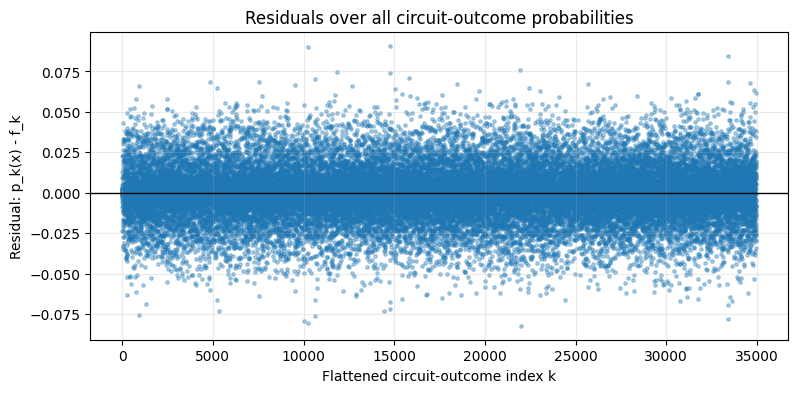

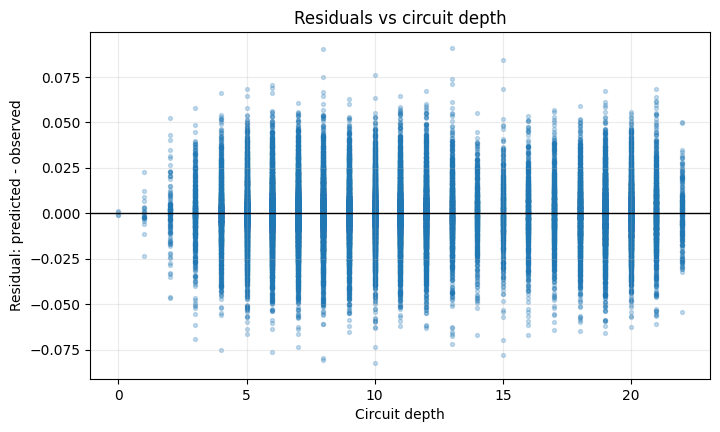

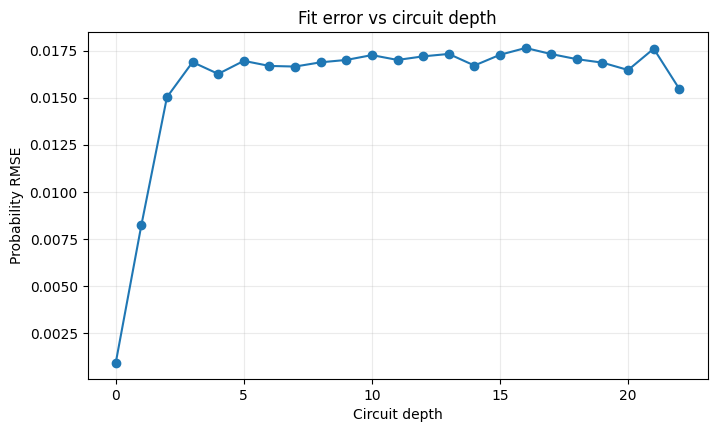

In [29]:
import math
import numpy as np
import matplotlib.pyplot as plt


def choose_fit_model(results, target_model):
    """Extract the final model from pyGSTi results, with a target-model fallback."""
    if results is None:
        print("No results object found; using target_model for plotting.")
        return target_model, "target_model"

    if not hasattr(results, "estimates") or len(results.estimates) == 0:
        print("Results has no estimates; using target_model for plotting.")
        return target_model, "target_model"

    estimate_name = list(results.estimates.keys())[-1]
    estimate = results.estimates[estimate_name]
    models = getattr(estimate, "models", {})

    for model_name in ["stdgaugeopt", "final iteration estimate", "go0", "target"]:
        if model_name in models:
            print(f"Using estimate '{estimate_name}' model '{model_name}'")
            return models[model_name], f"{estimate_name}:{model_name}"

    if len(models) > 0:
        model_name = list(models.keys())[-1]
        print(f"Using estimate '{estimate_name}' model '{model_name}'")
        return models[model_name], f"{estimate_name}:{model_name}"

    print("Could not find a model inside results; using target_model for plotting.")
    return target_model, "target_model"


def dataset_frequencies(dataset, circuit, outcomes):
    row = dataset[circuit]
    freqs = []
    for outcome in outcomes:
        try:
            freqs.append(float(row.fraction(outcome)))
        except Exception:
            total = float(row.total)
            freqs.append(float(row.counts.get(outcome, 0.0)) / total if total > 0 else np.nan)
    return np.asarray(freqs, dtype=float)


def model_probabilities_for_outcomes(model, circuit, outcomes):
    probs = model.probabilities(circuit)
    return np.asarray([float(probs.get(outcome, 0.0)) for outcome in outcomes], dtype=float)


def circuit_depth(circuit):
    try:
        return len(circuit)
    except Exception:
        return np.nan


fit_model, fit_model_name = choose_fit_model(globals().get("results", None), target_model)


observed = []
predicted = []
depths = []
outcome_labels = []

for circuit in list_of_experiments:
    row = dataset[circuit]
    outcomes = list(row.outcomes)
    obs = dataset_frequencies(dataset, circuit, outcomes)
    pred = model_probabilities_for_outcomes(fit_model, circuit, outcomes)

    observed.extend(obs)
    predicted.extend(pred)
    depths.extend([circuit_depth(circuit)] * len(outcomes))
    outcome_labels.extend(outcomes)

observed = np.asarray(observed, dtype=float)
predicted = np.asarray(predicted, dtype=float)
depths = np.asarray(depths, dtype=float)
residuals = predicted - observed
rmse = math.sqrt(np.nanmean(residuals**2))

print("Fit model:", fit_model_name)
print("Number of circuits:", len(list_of_experiments))
print("Number of probability entries:", len(observed))
print(f"Probability RMSE: {rmse:.6e}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(np.arange(len(residuals)), residuals, s=6, alpha=0.35)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Flattened circuit-outcome index k")
ax.set_ylabel("Residual: p_k(x) - f_k")
ax.set_title("Residuals over all circuit-outcome probabilities")
ax.grid(True, alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(depths, residuals, s=8, alpha=0.25)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Circuit depth")
ax.set_ylabel("Residual: predicted - observed")
ax.set_title("Residuals vs circuit depth")
ax.grid(True, alpha=0.25)
plt.show()

unique_depths = np.array(sorted(set(depths[np.isfinite(depths)])), dtype=float)
rmse_by_depth = []
for depth in unique_depths:
    mask = depths == depth
    rmse_by_depth.append(math.sqrt(np.nanmean(residuals[mask] ** 2)))
rmse_by_depth = np.asarray(rmse_by_depth)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(unique_depths, rmse_by_depth, marker="o", linewidth=1.5)
ax.set_xlabel("Circuit depth")
ax.set_ylabel("Probability RMSE")
ax.set_title("Fit error vs circuit depth")
ax.grid(True, alpha=0.25)
plt.show()

### 2.2 Built-In LM Superoperator Heatmaps

These heatmaps are gauge-dependent diagnostics. They are useful for visual inspection, but they should not be the primary pre-gauge solver comparison.


Plotting operation labels:
   Gxpi2:1
   Gypi2:1
   Gxpi2:0
   Gypi2:0
   Gcnot:0:1


/tmp/ipykernel_627/2065742403.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


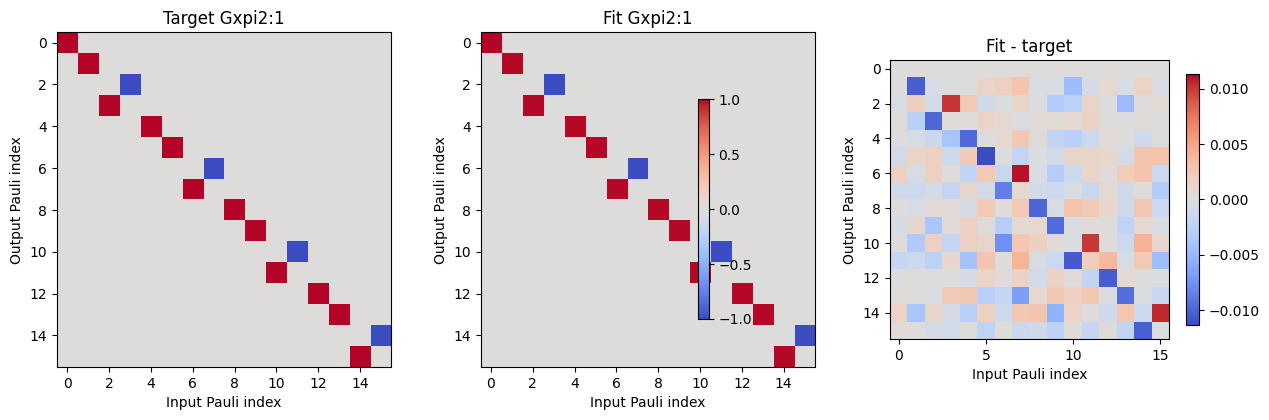

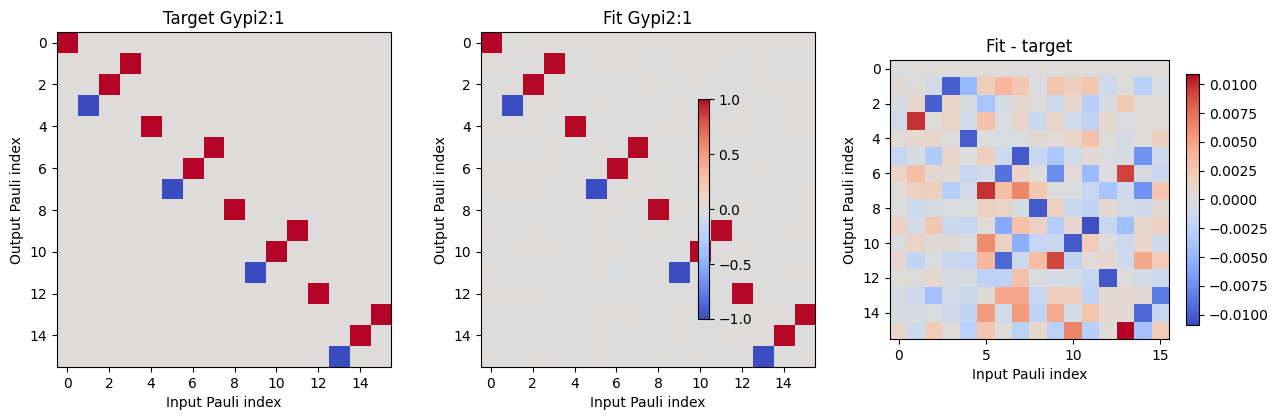

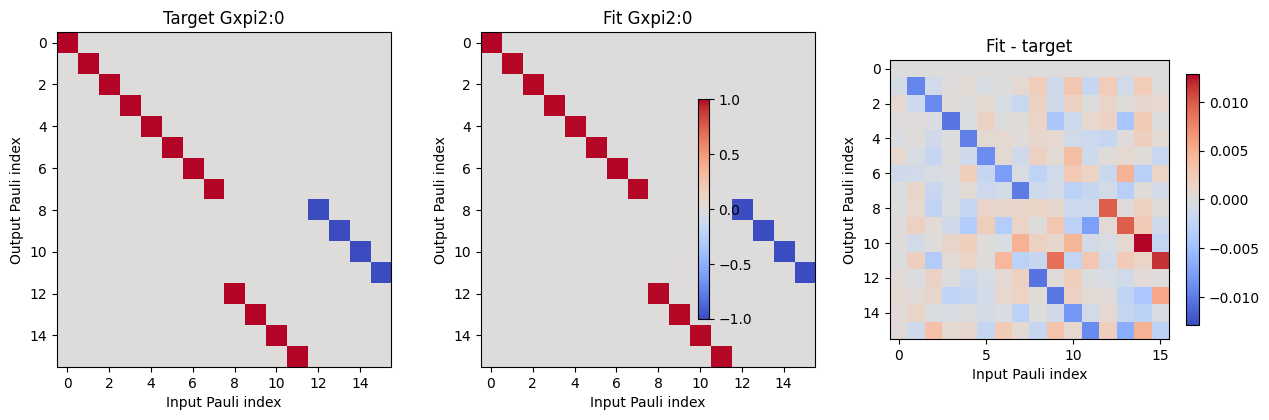

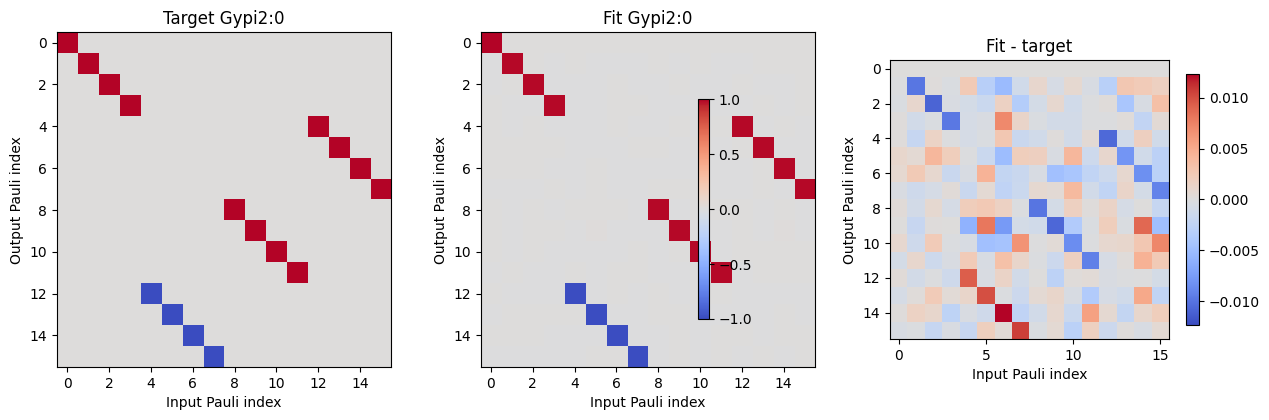

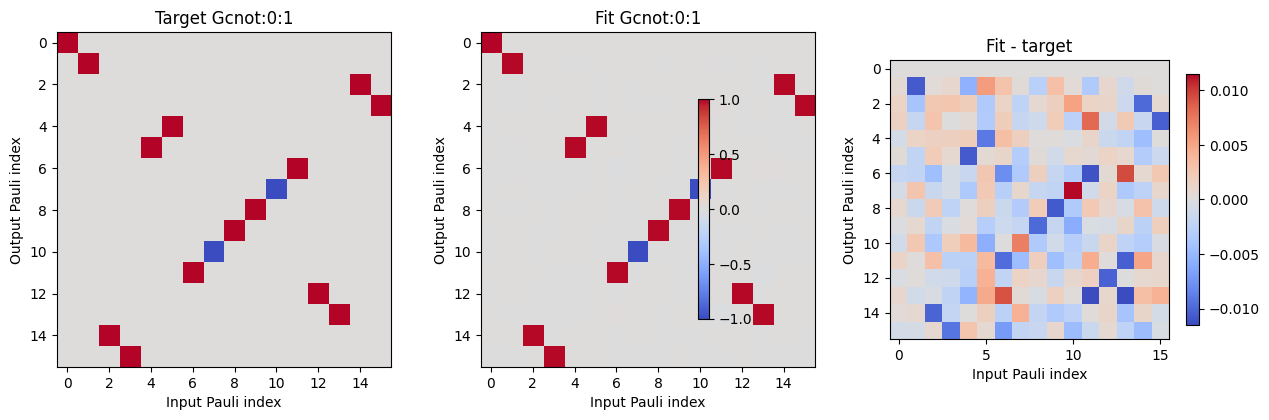

In [30]:
def op_matrix(model, label):
    ops = getattr(model, "operations", None)
    if ops is None:
        ops = getattr(model, "gates", None)
    op = ops[label]
    try:
        return np.asarray(op.to_dense(), dtype=float)
    except Exception:
        return np.asarray(op, dtype=float)


def shared_operation_labels(model_a, model_b):
    ops_a = getattr(model_a, "operations", getattr(model_a, "gates", {}))
    ops_b = getattr(model_b, "operations", getattr(model_b, "gates", {}))
    return [label for label in ops_a.keys() if label in ops_b]


labels = [label for label in shared_operation_labels(target_model, fit_model) if str(label) not in {"[]", "Gi", "I"}]
print("Plotting operation labels:")
for label in labels:
    print("  ", label)

for label in labels:
    target_ptm = op_matrix(target_model, label)
    fit_ptm = op_matrix(fit_model, label)
    diff_ptm = fit_ptm - target_ptm
    vmax = max(np.max(np.abs(target_ptm)), np.max(np.abs(fit_ptm)), 1e-12)
    diff_vmax = max(np.max(np.abs(diff_ptm)), 1e-12)

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    images = [
        axes[0].imshow(target_ptm, vmin=-vmax, vmax=vmax, cmap="coolwarm"),
        axes[1].imshow(fit_ptm, vmin=-vmax, vmax=vmax, cmap="coolwarm"),
        axes[2].imshow(diff_ptm, vmin=-diff_vmax, vmax=diff_vmax, cmap="coolwarm"),
    ]
    axes[0].set_title(f"Target {label}")
    axes[1].set_title(f"Fit {label}")
    axes[2].set_title("Fit - target")
    for ax in axes:
        ax.set_xlabel("Input Pauli index")
        ax.set_ylabel("Output Pauli index")
    fig.colorbar(images[0], ax=axes[:2], shrink=0.75)
    fig.colorbar(images[2], ax=axes[2], shrink=0.75)
    fig.tight_layout()
    plt.show()

## 3. Run the Custom POUNDERS/PyROL Optimizer

This section configures the full GST parameter vector optimization and runs the custom optimizer on the same dataset.


In [31]:
# Configure full-parameter gradient POUNDERS for GST.
# This uses the full GST parameter vector, not a reduced/sliced parameterization.

import sys

import gradient_pounders as pounders
pounders = importlib.reload(pounders)
import general_h_funs
general_h_funs = importlib.reload(general_h_funs)
h_leastsquares = general_h_funs.h_leastsquares
combine_leastsquares = general_h_funs.combine_leastsquares

class NotebookPoundersLogger:
    def __init__(self, enabled=True):
        self.enabled = enabled

    def log(self, source, message, level=None):
        if self.enabled:
            print(f"[{source}] {message}")


base_model_for_pounders = active_model
x0_full = np.asarray(base_model_for_pounders.to_vector(), dtype=float).reshape(-1)

all_pounders_circuits = list(gst_circuits) if "gst_circuits" in globals() else _resolve_circuits()

# None means use all GST circuits. You can set an integer only if you intentionally
# want a smaller debugging problem while still optimizing all model parameters.
# POUNDERS_NUM_CIRCUITS is defined in the configuration cell above.
if POUNDERS_NUM_CIRCUITS is None:
    pounders_circuits = all_pounders_circuits
else:
    pounders_circuits = all_pounders_circuits[:POUNDERS_NUM_CIRCUITS]


def gst_pounders_full_function(x):
    """Return full-GST residual and Jacobian in the layout expected by POUNDERS.

    F has shape (m,).
    J has shape (n, m), where n is the full number of GST parameters.
    """
    return gst_pounders_residual_function(
        x,
        model_template=base_model_for_pounders,
        circuits=pounders_circuits,
        data=dataset,
        weighted=False,
    )


# n [int] Dimension of the full GST optimization variable.
n = int(x0_full.size)

# X0 [dbl] Initial point. This is the full GST parameter vector.
X0 = x0_full.reshape(1, n)

# nfmax [int] Maximum number of function evaluations.
nfmax = POUNDERS_NFMAX

# gtol [dbl] Tolerance for the model-gradient norm.
gtol = POUNDERS_GTOL

# delta [dbl] Initial trust-region radius in full GST parameter space.
delta = POUNDERS_INITIAL_DELTA

# m [int] Number of residuals.
f_preview, _ = gst_data_function(data=dataset, circuits=pounders_circuits)
m = int(f_preview.size)

# Unbounded model parameters. The trust-region subproblem still receives finite
# step bounds, so this is compatible with spsolver=2 / MINQ.
Low = -np.inf * np.ones(n)
Upp = np.inf * np.ones(n)

logger = NotebookPoundersLogger(enabled=True)

# Prefer PyROL for the trust-region subproblem solver when it is installed.
# Fall back to MINQ/minqsw only when MINQ is available.
HAS_PYROL = importlib.util.find_spec("pyrol") is not None or importlib.util.find_spec("ROL") is not None
if PREFER_PYROL and HAS_PYROL:
    spsolver = 3
else:
    MINQ_PATHS = [
        Path.cwd().parent / "minq" / "py" / "minq5",
        Path.cwd() / "minq" / "py" / "minq5",
    ]
    for _minq_path in MINQ_PATHS:
        if (_minq_path / "minqsw.py").exists():
            if str(_minq_path) not in sys.path:
                sys.path.insert(0, str(_minq_path))
            break
    if importlib.util.find_spec("minqsw") is None:
        raise ModuleNotFoundError(
            "Neither PyROL/ROL nor MINQ is importable. Install pyroltrilinos, or mount/clone MINQ next to this repo."
        )
    from minqsw import minqsw
    spsolver = 2
    if PREFER_PYROL:
        print("PyROL/ROL is not installed in this Python environment; using MINQ instead.")

estimated_j_history_gb = nfmax * n * m * 8 / (1024**3)
print(f"Prepared full-GST gradient POUNDERS problem: n={n}, m={m}")
print(f"Using {len(pounders_circuits)} GST circuits.")
print(f"spsolver={spsolver} ({'PyROL' if spsolver == 3 else 'MINQ'}).")
print("Using combine_leastsquares with implicit Hres dimensions, so no dense Hres tensor is allocated.")

Prepared full-GST gradient POUNDERS problem: n=1616, m=34960
Using 8740 GST circuits.
spsolver=3 (PyROL).
Using combine_leastsquares with implicit Hres dimensions, so no dense Hres tensor is allocated.


In [32]:
if RUN_POUNDERS:
    X, F, J, flag, xkin = pounders.pouders(
        gst_pounders_full_function,
        X0,
        n,
        nfmax,
        gtol,
        delta,
        m,
        Low,
        Upp,
        logger,
        spsolver=spsolver,
        hfun=h_leastsquares,
        combinemodels=combine_leastsquares,
    )

    pounders_best_index = int(xkin)
    pounders_x_best = np.asarray(X[pounders_best_index], dtype=float)
    pounders_fit_model = base_model_for_pounders.copy()
    pounders_fit_model.from_vector(pounders_x_best)

    print("POUNDERS finished.")
    print("flag:", flag)
    print("xkin:", xkin)
    print("best GST parameter vector shape:", pounders_x_best.shape)
    print("best GST objective:", h_leastsquares(F[pounders_best_index]))
else:
    X = F = J = None
    flag = xkin = None
    pounders_fit_model = None
    print("Skipped POUNDERS because RUN_POUNDERS=False")

[POUDERS] Beginning gradient-based optimization.
[POUDERS] Initial residual/Jacobian evaluation took 21.96 seconds.
[POUDERS] Initial point evaluated.
[POUDERS] nf: 0, f(x) = 36.130976000000175
[POUDERS] Model combine took 1.44 seconds.
[POUDERS] nf: 0, delta: 0.1, f(x): 36.130976000000175, ng: 1157.3933508529428
[POUDERS] Starting PyROL trust-region solve with n=1616.

Truncated CG Trust-Region Solver
Trust-Region Model: Kelley-Sachs
  iter  value          gnorm          snorm          delta          #fval     #grad     tr_flag   iterCG    flagCG    
  0     0.000000e+00   3.807689e+00                  1.303373e-09   
  1     -1.318383e+00  3.808182e+00   1.303373e-09   3.258433e-09   8         3         0         1         3         
  2     -2.554876e+00  3.808644e+00   3.258433e-09   8.146083e-09   14        5         0         1         3         
  3     -3.714883e+00  3.808944e+00   8.146083e-09   2.036521e-08   20        7         0         1         3         
  4     -4.80344

## 4. Compare Both Solvers

Compare LM and POUNDERS/PyROL first using gauge-independent data-space metrics. Heatmaps are kept after the numerical table as gauge-dependent diagnostics.


### 4.1 Gauge-Independent Data-Space Metrics


In [35]:
def _row_outcomes(data, circuit):
    return list(data[circuit].outcomes)


def _observed_probs(data, circuit, outcomes):
    row = data[circuit]
    total = float(row.total)
    values = []
    for outcome in outcomes:
        try:
            values.append(float(row.fraction(outcome)))
        except Exception:
            values.append(float(row.counts.get(outcome, 0.0)) / total if total > 0 else np.nan)
    return np.asarray(values, dtype=float)


def _predicted_probs(model, circuit, outcomes):
    probs = model.probabilities(circuit)
    return np.asarray([float(probs.get(outcome, 0.0)) for outcome in outcomes], dtype=float)


def data_space_metrics(name, model, circuits, data, variance_floor=1e-12):
    residuals = []
    weighted_terms = []
    tv_values = []

    for circuit in circuits:
        outcomes = _row_outcomes(data, circuit)
        observed = _observed_probs(data, circuit, outcomes)
        predicted = _predicted_probs(model, circuit, outcomes)
        residual = predicted - observed
        residuals.extend(residual)
        tv_values.append(0.5 * np.sum(np.abs(residual)))

        shots = float(data[circuit].total)
        variance = np.maximum(observed * (1.0 - observed) / shots, variance_floor)
        weighted_terms.extend((residual ** 2) / variance)

    residuals = np.asarray(residuals, dtype=float)
    weighted_terms = np.asarray(weighted_terms, dtype=float)
    tv_values = np.asarray(tv_values, dtype=float)

    return {
        "solver": name,
        "num_circuits": len(circuits),
        "num_probability_entries": residuals.size,
        "objective_sum_sq": float(np.sum(residuals ** 2)),
        "rmse": float(np.sqrt(np.mean(residuals ** 2))),
        "weighted_chi2": float(np.sum(weighted_terms)),
        "mean_tv_per_circuit": float(np.mean(tv_values)),
        "max_abs_residual": float(np.max(np.abs(residuals))),
    }


def reconstruct_pounders_fit_model():
    """Rebuild the fitted GST model from the best POUNDERS parameter vector."""
    if "pounders_fit_model" in globals() and pounders_fit_model is not None:
        return pounders_fit_model

    if "X" not in globals() or "xkin" not in globals():
        return None

    model_template = globals().get("base_model_for_pounders", globals().get("active_model", target_model))
    best_index = int(xkin)
    x_best = np.asarray(X[best_index], dtype=float)
    model = model_template.copy()
    model.from_vector(x_best)
    return model


# Use all GST circuits for a prediction-quality comparison.
# To compare only on the POUNDERS training subset, use:
# METRICS_CIRCUITS = pounders_circuits
METRICS_CIRCUITS = list_of_experiments

comparison_models = []
if "fit_model" in globals() and fit_model is not None:
    comparison_models.append(("pyGSTi LM", fit_model))
else:
    print("pyGSTi LM model not found. Run the LM baseline and diagnostics cells first.")

pounders_model_for_metrics = reconstruct_pounders_fit_model()
if pounders_model_for_metrics is not None:
    comparison_models.append(("POUNDERS/PyROL", pounders_model_for_metrics))
else:
    print("POUNDERS/PyROL model not found. Run the POUNDERS optimization cell first.")

print("Evaluating metrics on", len(METRICS_CIRCUITS), "circuits.")
rows = [data_space_metrics(name, model, METRICS_CIRCUITS, dataset) for name, model in comparison_models]

if not rows:
    print("No fitted models available yet. Run the LM and/or POUNDERS cells first.")
else:
    try:
        import pandas as pd
        metrics_df = pd.DataFrame(rows)
        display(metrics_df)
    except Exception:
        for row in rows:
            print(row)

Evaluating metrics on 8740 circuits.


/usr/local/lib/python3.11/site-packages/pygsti/tools/legacytools.py:38: UserWarning: The function fraction is deprecated, and may not be present in future versions of pygsti.
    Please use DataSetRow.fractions instead.
  _warnings.warn(message)


,solver,num_circuits,num_probability_entries,objective_sum_sq,rmse,weighted_chi2,mean_tv_per_circuit,max_abs_residual
0,pyGSTi LM,8740,34960,10.002576,0.016915,9.142843e+08,0.025005,0.090931
1,POUNDERS/PyROL,8740,34960,9.852214,0.016787,9.681817e+08,0.024969,0.090157


### 4.2 POUNDERS/PyROL Superoperator Heatmaps

These are gauge-dependent diagnostics for the custom optimizer result. For gate-level numerical comparison, gauge-optimize both fitted models to the same target first.


Available operation labels: ['[]', 'Gxpi2:1', 'Gypi2:1', 'Gxpi2:0', 'Gypi2:0', 'Gcnot:0:1']
best eval index: 15
best objective: 9.852213706463333
plotting operations: ['Gxpi2:1', 'Gypi2:1', 'Gxpi2:0', 'Gypi2:0', 'Gcnot:0:1']


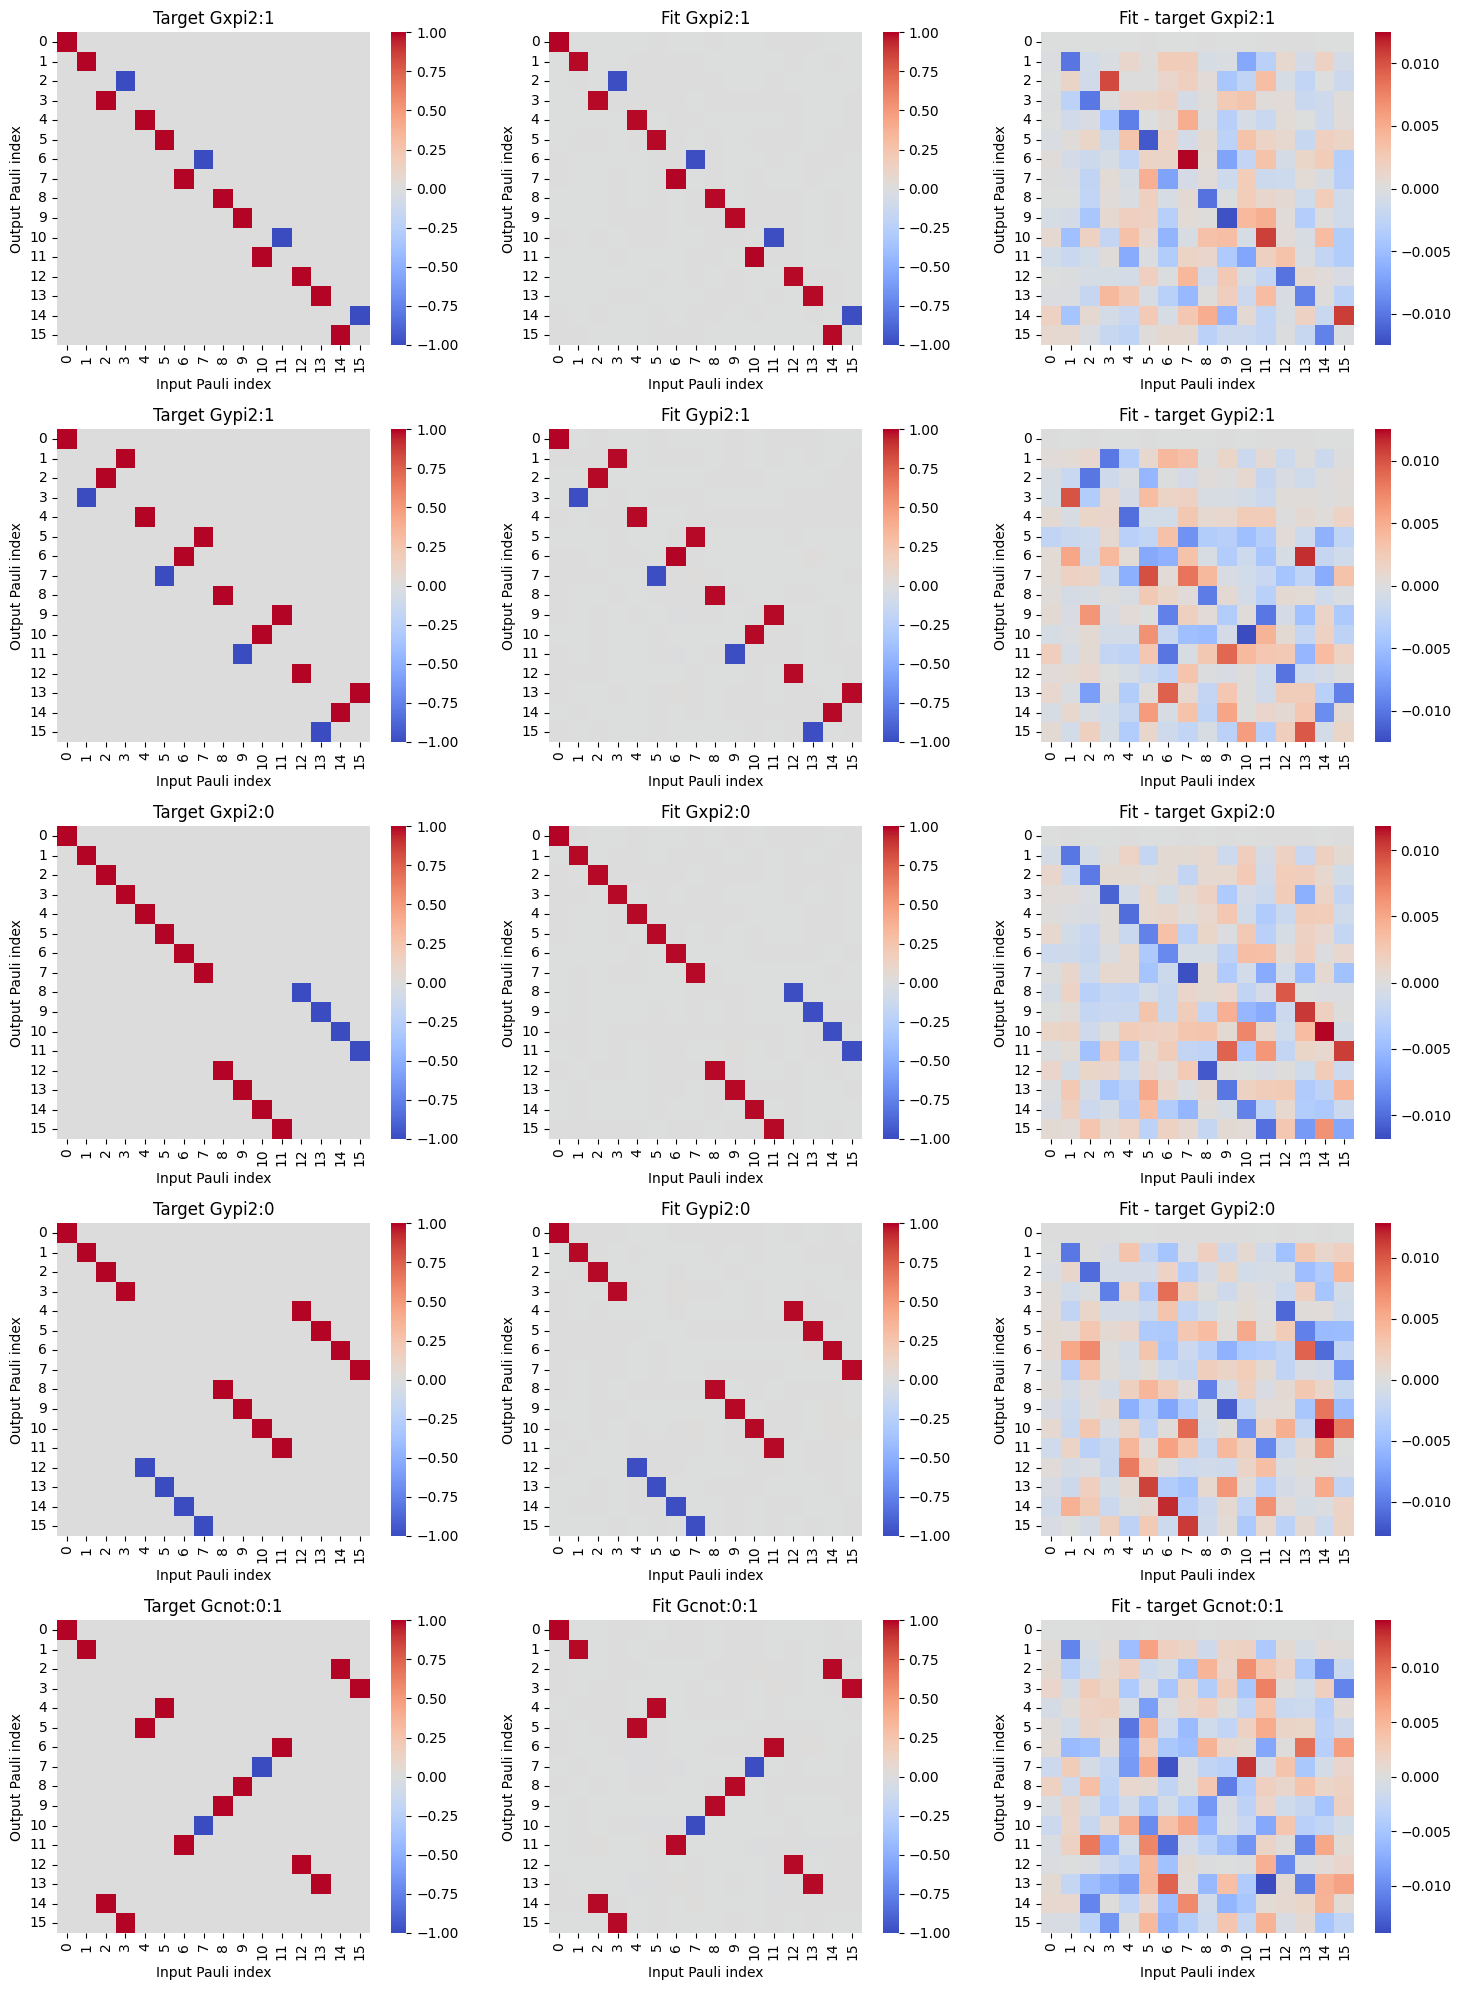

In [34]:
# Plot POUNDERS/PyROL fitted superoperator heatmaps for all gates.
# These heatmaps are gauge-dependent, so use them as diagnostics after checking data-space metrics.

import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if "X" not in globals() or "xkin" not in globals():
    raise RuntimeError("Run the POUNDERS optimization cell first.")

# xkin is the best/current center returned by POUNDERS.
best_eval_index = int(xkin)
x_best = np.asarray(X[best_eval_index], dtype=float)

pounders_fit_model = base_model_for_pounders.copy()
pounders_fit_model.from_vector(x_best)

reference_model = globals().get("target_model", globals().get("base_model_for_pounders", active_model))

available_gate_labels = list(pounders_fit_model.operations.keys())
print("Available operation labels:", [str(label) for label in available_gate_labels])

# Plot all non-identity operations by default.
# To plot selected gates, set e.g. HEATMAP_GATE_LABELS = ["Gxpi2:0", "Gcnot:0:1"].
HEATMAP_GATE_LABELS = None
INCLUDE_IDENTITY_HEATMAP = False

def label_matches(label, requested_label):
    return label == requested_label or str(label) == str(requested_label)

if HEATMAP_GATE_LABELS is None:
    gate_labels_to_plot = [
        label for label in available_gate_labels
        if INCLUDE_IDENTITY_HEATMAP or str(label) not in {"[]", "Gi", "I"}
    ]
else:
    gate_labels_to_plot = []
    for requested_label in HEATMAP_GATE_LABELS:
        matches = [label for label in available_gate_labels if label_matches(label, requested_label)]
        if not matches:
            raise ValueError(f"Could not find gate label {requested_label!r}. Choose one from the printed labels.")
        gate_labels_to_plot.append(matches[0])

if not gate_labels_to_plot:
    raise RuntimeError("No gates selected for plotting. Set INCLUDE_IDENTITY_HEATMAP=True or choose HEATMAP_GATE_LABELS.")

def operation_matrix(model, label):
    op = model.operations[label]
    if hasattr(op, "to_dense"):
        return np.asarray(op.to_dense(), dtype=float)
    if hasattr(op, "todense"):
        return np.asarray(op.todense(), dtype=float)
    return np.asarray(op, dtype=float)

if "h_leastsquares" in globals() and "F" in globals():
    print("best eval index:", best_eval_index)
    print("best objective:", h_leastsquares(F[best_eval_index]))
print("plotting operations:", [str(label) for label in gate_labels_to_plot])

# One row per gate: target, optimized fit, and fit-target difference.
nrows = len(gate_labels_to_plot)
fig, axes = plt.subplots(nrows, 3, figsize=(15, 4 * nrows), squeeze=False)

for row, gate_label in enumerate(gate_labels_to_plot):
    target_gate = operation_matrix(reference_model, gate_label)
    fit_gate = operation_matrix(pounders_fit_model, gate_label)
    diff_gate = fit_gate - target_gate

    matrix_vmax = max(np.max(np.abs(target_gate)), np.max(np.abs(fit_gate)), 1e-12)
    diff_vmax = max(np.max(np.abs(diff_gate)), 1e-12)

    sns.heatmap(
        target_gate,
        ax=axes[row, 0],
        cmap="coolwarm",
        center=0,
        vmin=-matrix_vmax,
        vmax=matrix_vmax,
        square=True,
    )
    axes[row, 0].set_title(f"Target {gate_label}")

    sns.heatmap(
        fit_gate,
        ax=axes[row, 1],
        cmap="coolwarm",
        center=0,
        vmin=-matrix_vmax,
        vmax=matrix_vmax,
        square=True,
    )
    axes[row, 1].set_title(f"Fit {gate_label}")

    sns.heatmap(
        diff_gate,
        ax=axes[row, 2],
        cmap="coolwarm",
        center=0,
        vmin=-diff_vmax,
        vmax=diff_vmax,
        square=True,
    )
    axes[row, 2].set_title(f"Fit - target {gate_label}")

    for ax in axes[row, :]:
        ax.set_xlabel("Input Pauli index")
        ax.set_ylabel("Output Pauli index")

plt.tight_layout()
plt.show()